In [76]:
import pandas as pd 
import seaborn as sns
from pathlib import Path


In [77]:
#Load the dataset and find the most common gender and birth country
df=pd.read_csv(Path('nobel.csv'))
df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [78]:
 # extract the top values from sex and birth_country.
df['birth_country'].value_counts().idxmax()


'United States of America'

In [79]:
df['sex'].value_counts().index[0]

'Male'

In [80]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  1000 non-null   int64 
 1   category              1000 non-null   object
 2   prize                 1000 non-null   object
 3   motivation            912 non-null    object
 4   prize_share           1000 non-null   object
 5   laureate_id           1000 non-null   int64 
 6   laureate_type         1000 non-null   object
 7   full_name             1000 non-null   object
 8   birth_date            968 non-null    object
 9   birth_city            964 non-null    object
 10  birth_country         969 non-null    object
 11  sex                   970 non-null    object
 12  organization_name     736 non-null    object
 13  organization_city     735 non-null    object
 14  organization_country  735 non-null    object
 15  death_date            596 non-null    o

In [81]:
import numpy as np
# Identify the decade with the highest ratio of US-born winners
df['decade'] = (np.floor(df['year'] / 10) * 10).astype(int)
# df['decade'] = (df['year'] // 10) * 10

In [82]:
# Create the US-born winners column
#df['US-born']=df['birth_country']=='United States of America'
df['US-born_n']=np.where(df['birth_country']=='United States of America',1,0)

In [83]:
df.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country,decade,US-born_n
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany,1900,0
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France,1900,0
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany,1900,0
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland,1900,0
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France,1900,0


In [84]:
US_born=df.groupby('decade').agg(mean_u=('US-born_n','mean')).reset_index()
max_decade_usa=US_born.nlargest(1,'mean_u')['decade'].iloc[0]
max_decade_usa

np.int64(2000)

In [85]:
max_decade_usa.astype

<function int64.astype>

In [86]:
US_born.head()

,decade,mean_u
0,1900,0.017544
1,1910,0.075000
2,1920,0.074074
3,1930,0.250000
4,1940,0.302326


Text(0, 0.5, 'Percentage of US-born winners')

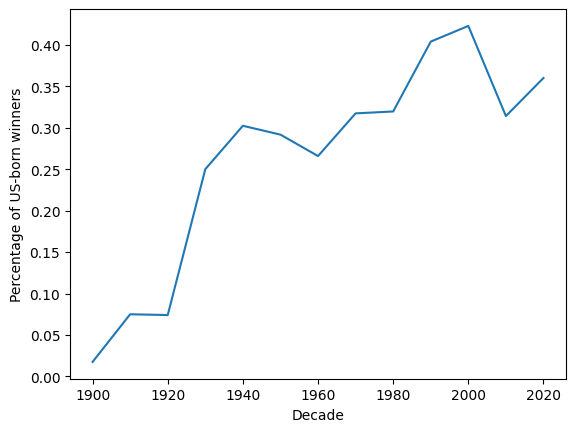

In [87]:
import matplotlib.pyplot as plt
sns.lineplot(
    data=US_born,
    x='decade',
    y='mean_u'
)
plt.xlabel('Decade')
plt.ylabel('Percentage of US-born winners')

In [88]:
#Find the decade and category with the highest proportion of female laureates

In [89]:
max_female=df[df['sex']=='Female'][['sex','decade','category']]
max_female=max_female.groupby(['sex','decade','category']).agg(count_f=('sex','count')).reset_index()
max_female.head()


,sex,decade,category,count_f
0,Female,1900,Literature,1
1,Female,1900,Peace,1
2,Female,1900,Physics,1
3,Female,1910,Chemistry,1
4,Female,1920,Literature,2


In [90]:
max_row = max_female.loc[max_female['count_f'].idxmax()]
max_row

sex         Female
decade        2010
category     Peace
count_f          5
Name: 30, dtype: object

<Axes: xlabel='decade', ylabel='count_f'>

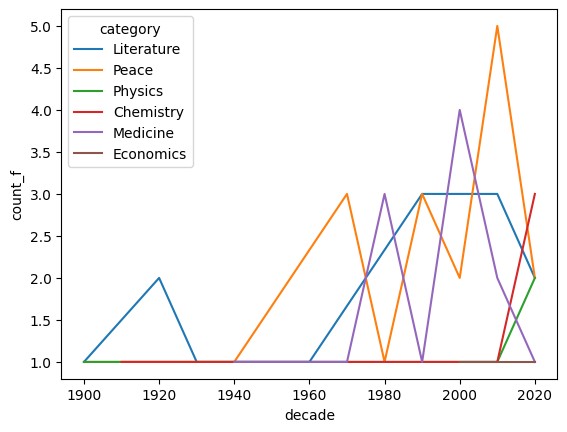

In [91]:
sns.lineplot(max_female,x='decade',y='count_f', hue='category')

In [ ]:
#Find first woman to win a Nobel Prize
first_woman=df[df['sex']=='Female'].nsmallest(1,'year')['full_name']
first_woman

19    Marie Curie, née Sklodowska
Name: full_name, dtype: object

In [97]:
#Determine repeat winners
repeat=df.groupby('full_name').agg(count=('full_name','count')).reset_index()
repeat.head()

,full_name,count
0,A. Michael Spence,1
1,Aage Niels Bohr,1
2,Aaron Ciechanover,1
3,Aaron Klug,1
4,Abdulrazak Gurnah,1


In [106]:
repeats=repeat[repeat['count']>1]['full_name'].tolist()
repeats

['Comité international de la Croix Rouge (International Committee of the Red Cross)',
 'Frederick Sanger',
 'John Bardeen',
 'Linus Carl Pauling',
 'Marie Curie, née Sklodowska',
 'Office of the United Nations High Commissioner for Refugees (UNHCR)']